In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('car_data_50_records.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check basic info
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows of the dataset:
   Car_ID   Brand    Model  Year  Price_USD  Mileage_km
0       1     Kia  Picanto  2015      13441       73945
1       2  Suzuki    Swift  2015      19284       73446
2       3     Kia   Cerato  2017      17539       16355
3       4  Suzuki   Cultus  2017      34661       13617
4       5   Honda   Accord  2023      20486       92526

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Car_ID      50 non-null     int64
 1   Brand       50 non-null     str  
 2   Model       50 non-null     str  
 3   Year        50 non-null     int64
 4   Price_USD   50 non-null     int64
 5   Mileage_km  50 non-null     int64
dtypes: int64(4), str(2)
memory usage: 2.5 KB
None

Statistical Summary:
         Car_ID         Year   Price_USD     Mileage_km
count  50.00000    50.000000     50.0000      50.000000
mean   25.50000  2019.400000  25

Missing values:
Car_ID        0
Brand         0
Model         0
Year          0
Price_USD     0
Mileage_km    0
dtype: int64


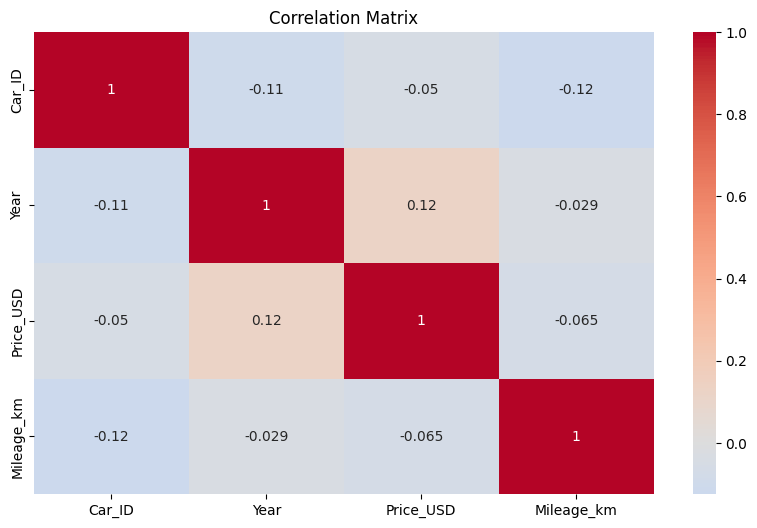

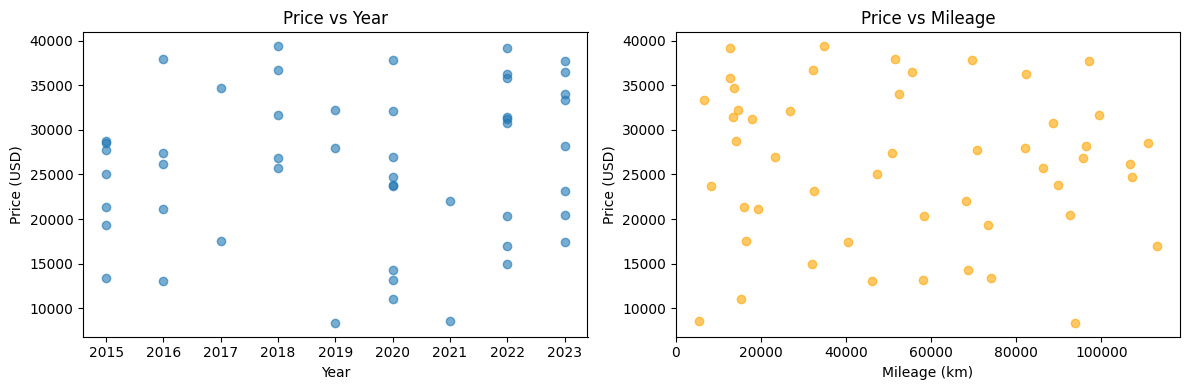

In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Visualize relationships
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price vs Year
axes[0].scatter(df['Year'], df['Price_USD'], alpha=0.6)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Price vs Year')

# Price vs Mileage
axes[1].scatter(df['Mileage_km'], df['Price_USD'], alpha=0.6, color='orange')
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('Price vs Mileage')

plt.tight_layout()
plt.show()

Simple Linear Regression (Price vs Year):
Coefficient: 475.57
Intercept: -933693.65
R² Score: -0.237
RMSE: 8802.78


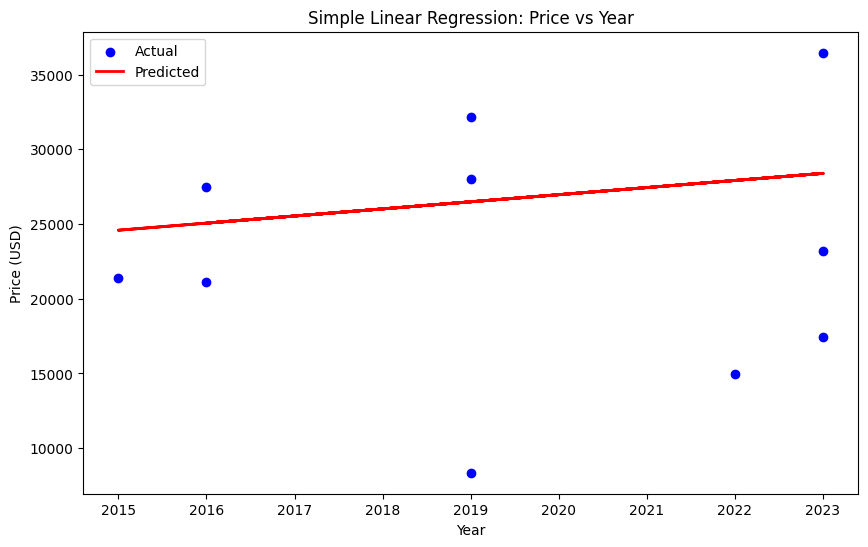

In [3]:
# Simple Linear Regression: Price vs Year
X_simple = df[['Year']]
y = df['Price_USD']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# Make predictions
y_pred_simple = simple_model.predict(X_test)

# Evaluate the model
print("Simple Linear Regression (Price vs Year):")
print(f"Coefficient: {simple_model.coef_[0]:.2f}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_simple):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.2f}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_simple, color='red', linewidth=2, label='Predicted')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.title('Simple Linear Regression: Price vs Year')
plt.legend()
plt.show()


Simple Linear Regression (Price vs Mileage):
Coefficient: -0.02
Intercept: 27679.36
R² Score: -0.215
RMSE: 8723.63


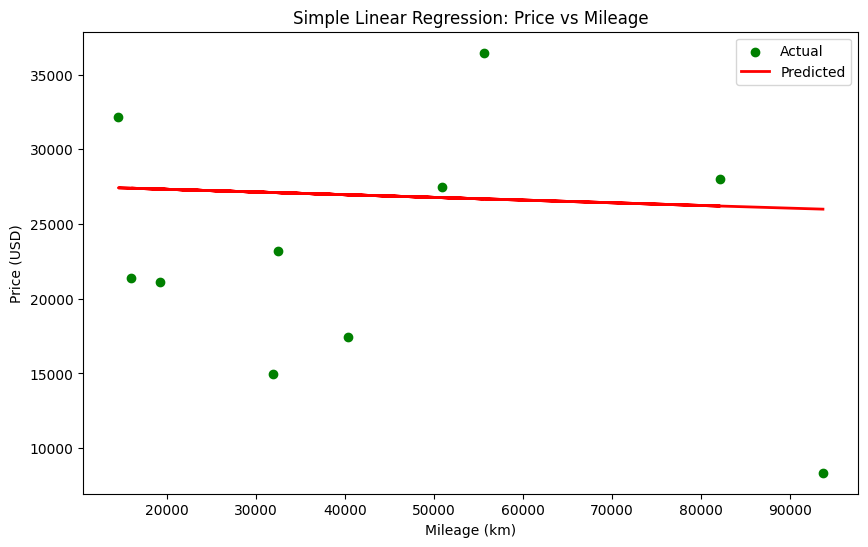

In [10]:
# Simple Linear Regression: Price vs Mileage
X_simple_mileage = df[['Mileage_km']]

# Split the data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_simple_mileage, y, test_size=0.2, random_state=42)

# Create and train the model
simple_model_m = LinearRegression()
simple_model_m.fit(X_train_m, y_train_m)

# Make predictions
y_pred_simple_m = simple_model_m.predict(X_test_m)

# Evaluate the model
print("\nSimple Linear Regression (Price vs Mileage):")
print(f"Coefficient: {simple_model_m.coef_[0]:.2f}")
print(f"Intercept: {simple_model_m.intercept_:.2f}")
print(f"R² Score: {r2_score(y_test_m, y_pred_simple_m):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_simple_m)):.2f}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test_m, y_test_m, color='green', label='Actual')
plt.plot(X_test_m, y_pred_simple_m, color='red', linewidth=2, label='Predicted')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (USD)')
plt.title('Simple Linear Regression: Price vs Mileage')
plt.legend()
plt.show()


Multiple Linear Regression:
R² Score: -0.431
RMSE: 9466.59

Top 5 Most Important Features:
          feature  coefficient
0            Year  2066.564359
9      Model_City  1598.823639
7     Model_Camry  1423.105554
14  Model_Picanto -1297.491665
3       Brand_Kia -1254.526408


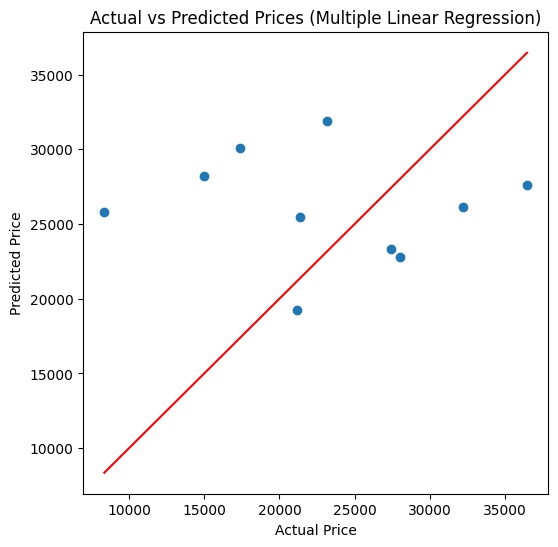

In [7]:
# Multiple Linear Regression with multiple features
# First, encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Brand', 'Model'], drop_first=True)

# Select features for multiple regression
feature_columns = ['Year', 'Mileage_km'] + [col for col in df_encoded.columns if col.startswith(('Brand_', 'Model_'))]
X_multi = df_encoded[feature_columns]
y_multi = df['Price_USD']

# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Standardize features (recommended for multiple regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

# Create and train the multiple regression model
multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train_multi)

# Make predictions
y_pred_multi = multi_model.predict(X_test_scaled)

# Evaluate the model
print("\nMultiple Linear Regression:")
print(f"R² Score: {r2_score(y_test_multi, y_pred_multi):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_multi, y_pred_multi)):.2f}")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': multi_model.coef_
})
print("\nTop 5 Most Important Features:")
print(feature_importance.sort_values('coefficient', key=abs, ascending=False).head())
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_multi, y_pred_multi)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")
plt.plot([y_test_multi.min(), y_test_multi.max()],
         [y_test_multi.min(), y_test_multi.max()],
         color='red')
plt.show()

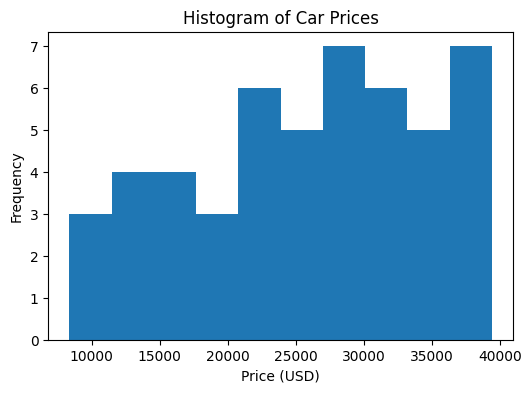

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Price_USD'], bins=10)
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Car Prices")
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("car_data_50_records.csv")

df.head()

,Car_ID,Brand,Model,Year,Price_USD,Mileage_km
0,1,Kia,Picanto,2015,13441,73945
1,2,Suzuki,Swift,2015,19284,73446
2,3,Kia,Cerato,2017,17539,16355
3,4,Suzuki,Cultus,2017,34661,13617
4,5,Honda,Accord,2023,20486,92526


In [7]:
df_encoded = pd.get_dummies(df, columns=['Brand','Model'], drop_first=True)

df_encoded.head()

,Car_ID,Year,Price_USD,Mileage_km,Brand_Hyundai,Brand_Kia,Brand_Suzuki,Brand_Toyota,Model_Alto,Model_Camry,...,Model_City,Model_Civic,Model_Corolla,Model_Cultus,Model_Elantra,Model_Picanto,Model_Sonata,Model_Sportage,Model_Swift,Model_Yaris
0,1,2015,13441,73945,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,2015,19284,73446,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,3,2017,17539,16355,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2017,34661,13617,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,5,2023,20486,92526,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Convert categorical columns 'Brand' and 'Model' to dummy variables
df_encoded = pd.get_dummies(df, columns=['Brand', 'Model'], drop_first=True)
df_encoded.head()

,Car_ID,Year,Price_USD,Mileage_km,Brand_Hyundai,Brand_Kia,Brand_Suzuki,Brand_Toyota,Model_Alto,Model_Camry,...,Model_City,Model_Civic,Model_Corolla,Model_Cultus,Model_Elantra,Model_Picanto,Model_Sonata,Model_Sportage,Model_Swift,Model_Yaris
0,1,2015,13441,73945,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,2015,19284,73446,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,3,2017,17539,16355,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2017,34661,13617,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,5,2023,20486,92526,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# List of numeric columns
numeric_cols = ['Year', 'Mileage_km', 'Price_USD']

# Remove commas (if any) and convert to numeric
for col in numeric_cols:
    df_encoded[col] = df_encoded[col].astype(str).str.replace(',', '')  # remove commas
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')   # convert to numeric

# Drop any rows that became NaN after conversion
df_encoded = df_encoded.dropna()

In [11]:
df_encoded.dtypes

Car_ID            int64
Year              int64
Price_USD         int64
Mileage_km        int64
Brand_Hyundai      bool
Brand_Kia          bool
Brand_Suzuki       bool
Brand_Toyota       bool
Model_Alto         bool
Model_Camry        bool
Model_Cerato       bool
Model_City         bool
Model_Civic        bool
Model_Corolla      bool
Model_Cultus       bool
Model_Elantra      bool
Model_Picanto      bool
Model_Sonata       bool
Model_Sportage     bool
Model_Swift        bool
Model_Yaris        bool
dtype: object

In [12]:
# Select features (independent variables)
feature_columns = ['Year', 'Mileage_km'] + [col for col in df_encoded.columns if col.startswith(('Brand_','Model_'))]

X = df_encoded[feature_columns].values  # feature matrix
y = df_encoded['Price_USD'].values      # target vector

# Add intercept column (for theta_0)
X = np.hstack((np.ones((X.shape[0],1)), X))

In [14]:
# Make sure X is completely numeric
X = df_encoded[feature_columns].copy()  # get features
X = np.hstack((np.ones((X.shape[0],1)), X.values.astype(np.float64)))  # add intercept & convert to float64

# Target as float64
y = df_encoded['Price_USD'].values.astype(np.float64)

In [15]:
theta = np.linalg.inv(X.T @ X) @ X.T @ y
print("Model Coefficients (θ):")
print(theta)

Model Coefficients (θ):
[-5.27192565e+07  2.62095006e+04 -1.89256700e-02 -2.89487794e+04
  1.38307689e+05 -4.00588980e+05  1.80080049e+05  2.27901295e+05
 -3.23548948e+05 -2.35934875e+05 -4.41483387e+04 -8.28852910e+04
 -3.69641782e+05  1.90870913e+05 -1.61078749e+05 -3.00142823e+05
 -6.91094468e+04 -2.69881879e+05  2.31917996e+05 -4.03782638e+05]


In [16]:
print(X.dtype)  # should show float64

float64


In [17]:
# Predict prices using our model
y_pred = X @ theta

# Check the first 5 predictions
print("First 5 Predicted Prices:")
print(y_pred[:5])

First 5 Predicted Prices:
[-70347.44650255 -77173.85228554  47369.4324689  -64669.63027279
 300812.03404095]


In [18]:
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)

r2 = 1 - (ss_residual / ss_total)
print("R² Score:", r2)

R² Score: -179.18732489418704


In [ ]:
rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)